In [69]:
!pip install git+https://github.com/amidos2006/pcg_benchmark.git
!pip install cma

  Cloning https://github.com/amidos2006/pcg_benchmark.git to /tmp/pip-req-build-1dak3lb0
  Running command git clone --filter=blob:none --quiet https://github.com/amidos2006/pcg_benchmark.git /tmp/pip-req-build-1dak3lb0
  Resolved https://github.com/amidos2006/pcg_benchmark.git to commit cd0f55b26c412a26e8797193e5417f5e651cf6cd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
import os
import random
import time
import math
from dataclasses import dataclass, field
from typing import List, Optional
 
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import pickle
import pcg_benchmark

loderunner_env = pcg_benchmark.make('loderunnertile-v0')

cuda


## Map data Extraction

##### Extract Maps Data

In [2]:
maps_folder = './maps'
maps_files = os.listdir(f"{maps_folder}")
nb_maps = len(maps_files)
print(f"nb_maps={nb_maps}")

nb_maps=150


#### Convert all Data into Tensor

In [3]:
nb_tiles_types = 7
nb_map_rows = 21
nb_map_cols = 32
map_size = 32

tile_to_number_dict = dict()
tile_to_number_dict['B'] = 0 # Solid Tile
tile_to_number_dict['b'] = 0 # Solid Tile (but diggable)
tile_to_number_dict['.'] = 1 # Empty Tile
tile_to_number_dict['M'] = 2 # Player Tile
tile_to_number_dict['G'] = 3 # Gold Tile
tile_to_number_dict['E'] = 4 # Enemy Tile
tile_to_number_dict['#'] = 5 # Ladder Tile
tile_to_number_dict['-'] = 6 # Rope Tile


X = np.zeros((nb_maps, nb_map_rows, nb_map_cols), dtype=int)
for i, map_filename in enumerate(maps_files):
    with open(f'./maps/{map_filename}', 'r') as f:
        all_rows = f.readlines()
        for j, row in enumerate(all_rows):
            if j == 21: break # Ignore ground
            for k, tile in enumerate(row):
                if tile == '\n': continue
                X[i, j, k] = tile_to_number_dict[tile]

print(X.shape)
# 150 maps - 22 rows - 32 columns

(150, 21, 32)


#### Onehot and Padding

In [4]:
X_onehot = np.eye(nb_tiles_types, dtype='uint8')[X]
X_onehot = np.rollaxis(X_onehot, 3, 1)
print("X_oneshot.shape = ", X_onehot.shape) # 150 maps - 7 different tiles - 22 rows - 32 columns


X_train = np.zeros((X.shape[0], nb_tiles_types, 24, 32), dtype=np.float32)
X_train[:, 1, :, :] = 0.0  # Fill with solid blocks
X_train[:X.shape[0], :, :X.shape[1], :X.shape[2]] = X_onehot
print("X_train.shape = ", X_train.shape) # 150 maps - 7 different tiles - 32 rows - 32 columns (padded)

X_oneshot.shape =  (150, 7, 21, 32)
X_train.shape =  (150, 7, 24, 32)


In [5]:
X_tensor = torch.from_numpy(X_train).to(device)

## Training

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
@dataclass
class TrainConfig:
    # ── Data dimensions ──────────────────────────────────────────
    x: int = 7          # number of tile classes  (one-hot channels)
    n: int = 32          # map height (rows)
    m: int = 32          # map width  (cols)

    # ── Architecture ─────────────────────────────────────────────
    z_dim:       int   = 32    # latent noise dimension
    g_feat:      int   = 64    # generator base feature count
    d_feat:      int   = 64     # critic base feature count
    n_upsample:  int   = 3      # ConvTranspose2d upsample steps  (n,m must be divisible by 2^n_upsample)

    # ── Training ─────────────────────────────────────────────────
    epochs:      int   = 20
    batch_size:  int   = 15
    lr:          float = 1e-4
    betas:       tuple = (0.0, 0.9)   # Adam betas — (0, 0.9) recommended for WGAN-GP
    n_critic:    int   = 5            # critic updates per generator update
    lambda_ent:  float = 0.5          # entropy regularisation weight (push toward hard one-hot)
    lambda_dist: float = 0.0          # tile-frequency distribution loss weight (0 = disabled)

    # ── Optional: target tile frequency distribution ──────────────
    # Set lambda_dist > 0 and provide a tensor of shape (x,) summing to 1
    target_tile_freq: Optional[torch.Tensor] = None

    # ── Logging / IO ─────────────────────────────────────────────
    log_interval:    int = 50         # print every N generator steps
    sample_interval: int = 10         # save tile map images every N epochs
    save_dir:        str = "tilemap_dcgan_out"
    val_split:       float = 0.1      # fraction of data used for validation KL

In [8]:
class Generator(nn.Module):
    """
    z  →  (B, z_dim)
       →  project + reshape  →  (B, g_feat * 2^(n_upsample-1), init_h, init_w)
       →  n_upsample × ConvTranspose2d  →  (B, x, n, m)
       →  softmax(dim=1)   # probability simplex over tile classes
    """

    def __init__(self, cfg: TrainConfig):
        super().__init__()
        self.cfg     = cfg
        self.init_h  = cfg.n // (2 ** cfg.n_upsample)
        self.init_w  = cfg.m // (2 ** cfg.n_upsample)
        assert self.init_h >= 1 and self.init_w >= 1, (
            f"n={cfg.n}, m={cfg.m} must be divisible by 2^{cfg.n_upsample}={2**cfg.n_upsample}"
        )

        # Number of feature maps at the input of the first deconv layer
        self.base_feat = cfg.g_feat * (2 ** (cfg.n_upsample - 1))

        self.project = nn.Sequential(
            nn.Linear(cfg.z_dim, self.base_feat * self.init_h * self.init_w, bias=False),
            nn.BatchNorm1d(self.base_feat * self.init_h * self.init_w),
            nn.ReLU(inplace=True),
        )

        layers = []
        in_ch = self.base_feat
        for i in range(cfg.n_upsample):
            is_last = (i == cfg.n_upsample - 1)
            out_ch  = cfg.x if is_last else in_ch // 2
            layers += [nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False)]
            if not is_last:
                layers += [nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            in_ch = out_ch

        self.deconv = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.project(z)
        x = x.view(z.size(0), self.base_feat, self.init_h, self.init_w)
        x = self.deconv(x)                  # (B, X, N, M) — raw logits
        return torch.softmax(x, dim=1)      # probability over tile classes

In [9]:
class Critic(nn.Module):
    def __init__(self, cfg: TrainConfig):
        super().__init__()
        sn      = nn.utils.spectral_norm
        final_h = cfg.n // (2 ** cfg.n_upsample)
        final_w = cfg.m // (2 ** cfg.n_upsample)

        layers = []
        in_ch  = cfg.x
        feat   = cfg.d_feat
        for i in range(cfg.n_upsample):
            layers += [sn(nn.Conv2d(in_ch, feat, 4, 2, 1, bias=False))]
            layers += [nn.LeakyReLU(0.2, inplace=True)]
            in_ch = feat
            feat  = min(feat * 2, 512)

        self.conv    = nn.Sequential(*layers)
        self.flatten = nn.Flatten()
        self.linear  = sn(nn.Linear(in_ch * final_h * final_w, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(self.flatten(self.conv(x)))

In [10]:
def critic_loss(real_scores: torch.Tensor, fake_scores: torch.Tensor) -> torch.Tensor:
    return -(real_scores.mean() - fake_scores.mean())


def generator_loss(fake_scores: torch.Tensor) -> torch.Tensor:
    return -fake_scores.mean()


def gradient_penalty(
    critic: Critic,
    real: torch.Tensor,
    fake: torch.Tensor,
    device: torch.device,
) -> torch.Tensor:
    B     = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device).expand_as(real)
    interp = (alpha * real + (1 - alpha) * fake.detach()).requires_grad_(True)

    scores = critic(interp)
    grads  = torch.autograd.grad(
        outputs=scores,
        inputs=interp,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    grad_norm = grads.view(B, -1).norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()


def entropy_loss(fake_soft: torch.Tensor) -> torch.Tensor:
    """
    Penalise uncertain (spread-out) tile distributions.
    Pushes the generator toward confident, near-hard one-hot outputs.
    fake_soft: (B, X, N, M) with values in [0,1] summing to 1 along dim=1.
    """
    eps     = 1e-8
    entropy = -(fake_soft * (fake_soft + eps).log()).sum(dim=1)  # (B, N, M)
    return entropy.mean()


def tile_distribution_loss(
    fake_soft: torch.Tensor,
    target_freq: torch.Tensor,
) -> torch.Tensor:
    """
    MSE between the generator's average tile frequencies and the desired distribution.
    fake_soft:   (B, X, N, M)
    target_freq: (X,)  — should sum to 1
    """
    pred_freq = fake_soft.mean(dim=(0, 2, 3))   # (X,)
    return F.mse_loss(pred_freq, target_freq.to(fake_soft.device))



@torch.no_grad()
def tile_kl_divergence(
    real_batch: torch.Tensor,
    fake_soft: torch.Tensor,
    eps: float = 1e-8,
) -> float:
    """
    KL( real tile freq || generated tile freq ).
    Lower is better; 0 means identical distributions.
    real_batch: (B, X, N, M) — hard one-hot
    fake_soft:  (B, X, N, M) — soft probabilities
    """
    real_freq = real_batch.mean(dim=(0, 2, 3))   # (X,)
    fake_freq = fake_soft.mean(dim=(0, 2, 3))    # (X,)
    real_freq = (real_freq + eps) / (real_freq + eps).sum()
    fake_freq = (fake_freq + eps) / (fake_freq + eps).sum()
    return (real_freq * (real_freq / fake_freq).log()).sum().item()

In [11]:
@dataclass
class LossHistory:
    # Per-step
    critic_steps:  List[float] = field(default_factory=list)
    gen_steps:     List[float] = field(default_factory=list)
    gp_steps:      List[float] = field(default_factory=list)
    ent_steps:     List[float] = field(default_factory=list)

    # Per-epoch
    critic_epochs: List[float] = field(default_factory=list)
    gen_epochs:    List[float] = field(default_factory=list)
    gp_epochs:     List[float] = field(default_factory=list)
    ent_epochs:    List[float] = field(default_factory=list)
    w_dist_epochs: List[float] = field(default_factory=list)
    kl_epochs:     List[float] = field(default_factory=list)
    epoch_times:   List[float] = field(default_factory=list)

    # Internal accumulators
    _c: List[float] = field(default_factory=list, repr=False)
    _g: List[float] = field(default_factory=list, repr=False)
    _p: List[float] = field(default_factory=list, repr=False)
    _e: List[float] = field(default_factory=list, repr=False)

    def log_critic(self, loss_c, gp):
        self.critic_steps.append(loss_c)
        self.gp_steps.append(gp)
        self._c.append(loss_c)
        self._p.append(gp)

    def log_gen(self, loss_g, ent):
        self.gen_steps.append(loss_g)
        self.ent_steps.append(ent)
        self._g.append(loss_g)
        self._e.append(ent)

    def flush_epoch(self, kl: float, elapsed: float) -> dict:
        avg_c  = float(np.mean(self._c)) if self._c else 0.0
        avg_g  = float(np.mean(self._g)) if self._g else 0.0
        avg_gp = float(np.mean(self._p)) if self._p else 0.0
        avg_e  = float(np.mean(self._e)) if self._e else 0.0

        self.critic_epochs.append(avg_c)
        self.gen_epochs.append(avg_g)
        self.gp_epochs.append(avg_gp)
        self.ent_epochs.append(avg_e)
        self.w_dist_epochs.append(-avg_c)
        self.kl_epochs.append(kl)
        self.epoch_times.append(elapsed)

        for buf in (self._c, self._g, self._p, self._e):
            buf.clear()

        return dict(
            critic=avg_c, gen=avg_g, gp=avg_gp,
            entropy=avg_e, w_dist=-avg_c, kl=kl,
        )


def save_tilemap_grid(
    fake_soft: torch.Tensor,
    epoch: int,
    save_dir: str,
    n_show: int = 8,
) -> None:
    """
    Convert soft probabilities → argmax tile maps and save as a grid image.
    fake_soft: (B, X, N, M)
    """
    B, X, N, M = fake_soft.shape
    n_show = min(n_show, B)

    cols = 4
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    tile_maps = loderunner_env.render(fake_soft[:n_show].argmax(dim=1).cpu().numpy())  # (n_show, N, M)

    for i, ax in enumerate(axes):
        if i < n_show:
            ax.imshow(tile_maps[i])
            ax.set_title(f"Sample {i+1}", fontsize=8)
        ax.axis("off")

    fig.suptitle(f"Generated Tile Maps — Epoch {epoch}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(save_dir, f"tilemaps_epoch_{epoch:04d}.png")
    plt.savefig(path, dpi=120)
    plt.close()
    return path

def plot_loss_history(history: LossHistory, save_dir: str) -> None:
    epochs = range(1, len(history.critic_epochs) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("Tilemap DCGAN (WGAN-GP) — Training History",
                 fontsize=15, fontweight="bold")

    def _smooth(arr, frac=0.005):
        w = max(1, int(len(arr) * frac))
        if w < 2:
            return arr
        return np.convolve(arr, np.ones(w) / w, mode="valid").tolist()

    panels = [
        (axes[0, 0], history.critic_steps,  "#e74c3c", "Discriminator Loss (per step)",     "step"),
        (axes[0, 1], history.gen_steps,     "#3498db", "Generator Loss (per step)",  "step"),
    ]
    for ax, data, color, title, xlabel in panels:
        ax.plot(data, alpha=0.3, linewidth=0.5, color=color)
        ax.plot(_smooth(data), linewidth=1.5, color=color)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs, history.w_dist_epochs, "o-", markersize=3,
            color="#2ecc71", linewidth=2)
    ax.set_title("Wasserstein Distance (per epoch)")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(epochs, history.ent_epochs, "s-", markersize=3,
            color="#e67e22", linewidth=2)
    ax.set_title("Entropy Regularisation (per epoch)")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, "loss_history.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"  Loss curves saved → {path}")


def generate_maps(
    checkpoint_path: str,
    n_maps: int = 16,
    temperature: float = 1.0,
    device: Optional[str] = None,
) -> torch.Tensor:
    """
    Load a saved checkpoint and generate tile maps.

    Args:
        checkpoint_path: path to checkpoint_latest.pt
        n_maps:          number of maps to generate
        temperature:     < 1.0 → sharper/more deterministic maps
                         > 1.0 → more random/varied maps
        device:          'cuda', 'cpu', or None (auto-detect)

    Returns:
        tile_maps: (n_maps, N, M) int64 tensor of tile class indices
        soft_maps: (n_maps, X, N, M) float32 soft probabilities
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    dev = torch.device(device)

    ckpt = torch.load(checkpoint_path, map_location=dev)
    cfg  = ckpt["cfg"]
    gen  = Generator(cfg).to(dev)
    gen.load_state_dict(ckpt["gen_state"])
    gen.eval()

    with torch.no_grad():
        z     = torch.randn(n_maps, cfg.z_dim, device=dev)
        # Apply temperature before softmax by re-running through deconv with scaled logits.
        # Since Generator applies softmax internally, we bypass it for temperature scaling:
        x = gen.project(z)
        x = x.view(n_maps, gen.base_feat, gen.init_h, gen.init_w)
        logits    = gen.deconv(x)                          # raw logits
        soft_maps = torch.softmax(logits / temperature, dim=1)
        tile_maps = soft_maps.argmax(dim=1)                # (n_maps, N, M) int

    return tile_maps, soft_maps

In [12]:
def train(
    dataset_tensor: torch.Tensor,
    cfg: TrainConfig = TrainConfig(),
) -> LossHistory:
    """
    Train the tilemap DCGAN.

    Args:
        dataset_tensor: float32 tensor of shape (B, X, N, M) with one-hot encoded maps.
        cfg:            TrainConfig instance.

    Returns:
        LossHistory with per-step and per-epoch statistics.
    """
    os.makedirs(cfg.save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # ── Validate tensor ──────────────────────────────────────────
    assert dataset_tensor.ndim == 4,  "Expected tensor shape (B, X, N, M)"
    B_total, X, N, M = dataset_tensor.shape
    assert X == cfg.x, f"cfg.x={cfg.x} but tensor has {X} channels"
    assert N == cfg.n, f"cfg.n={cfg.n} but tensor has {N} rows"
    assert M == cfg.m, f"cfg.m={cfg.m} but tensor has {M} cols"
    dataset_tensor = dataset_tensor.float()

    # ── Train / val split
    n_val   = max(1, int(B_total * cfg.val_split))
    n_train = B_total - n_val
    train_ds, val_ds = random_split(
        TensorDataset(dataset_tensor),
        [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )
    # train_loader = DataLoader(
    #     train_ds, batch_size=cfg.batch_size, shuffle=True,
    #     num_workers=min(4, os.cpu_count() or 1),
    #     # pin_memory=(device.type == "cuda"),
    #     drop_last=True,
    # )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0,
        pin_memory=False,
        drop_last=True,
    )

    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, drop_last=False)

    # ── Models
    gen  = Generator(cfg).to(device)
    crit = Critic(cfg).to(device)
    print(f"\nGenerator  params: {sum(p.numel() for p in gen.parameters()):,}")
    print(f"Critic     params: {sum(p.numel() for p in crit.parameters()):,}\n")

    opt_gen  = torch.optim.Adam(gen.parameters(),  lr=cfg.lr, betas=cfg.betas)
    opt_crit = torch.optim.Adam(crit.parameters(), lr=cfg.lr, betas=cfg.betas)

    # Fixed noise for deterministic sample visualisation
    fixed_z = torch.randn(16, cfg.z_dim, device=device)

    history  = LossHistory()
    gen_step = 0

    print(f"{'─'*65}")
    print(f"  Tilemap DCGAN (WGAN-GP)  |  {cfg.epochs} epochs  "
          f"|  {n_train} train  {n_val} val")
    print(f"  λ_ent={cfg.lambda_ent}  "
          f"λ_dist={cfg.lambda_dist}  n_critic={cfg.n_critic}")
    print(f"{'─'*65}\n")

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        gen.train()
        crit.train()

        for (real,) in train_loader:
            real = real #.to(device)          # (B, X, N, M)
            B    = real.size(0)

            #  1. Train Critic  ×  n_critic
            for _ in range(cfg.n_critic):
                z    = torch.randn(B, cfg.z_dim, device=device)
                fake = gen(z).detach()      # soft (B, X, N, M)

                real_scores = crit(real)
                fake_scores = crit(fake)

                gp = 0
                loss_c = critic_loss(real_scores, fake_scores)

                opt_crit.zero_grad()
                loss_c.backward()
                opt_crit.step()

                history.log_critic(loss_c.item(), gp)

            #  2. Train Generator
            z    = torch.randn(B, cfg.z_dim, device=device)
            fake = gen(z)                   # soft (B, X, N, M)

            loss_g = generator_loss(crit(fake))
            loss_e = entropy_loss(fake)

            total_loss_g = loss_g + cfg.lambda_ent * loss_e

            if cfg.lambda_dist > 0 and cfg.target_tile_freq is not None:
                loss_d       = tile_distribution_loss(fake, cfg.target_tile_freq)
                total_loss_g = total_loss_g + cfg.lambda_dist * loss_d

            opt_gen.zero_grad()
            total_loss_g.backward()
            opt_gen.step()

            history.log_gen(loss_g.item(), loss_e.item())
            gen_step += 1

            if gen_step % cfg.log_interval == 0:
                w_dist = (crit(real).mean() - crit(fake.detach()).mean()).item()
                print(
                    f"  [ep {epoch:04d}  step {gen_step:07d}]  "
                    f"Disc {loss_c.item():+.4f}  "
                    f"Gen {loss_g.item():+.4f}  "
                    f"Ent {loss_e.item():.4f}  "
                    f"W {w_dist:.4f}"
                )

        # ── Epoch end: KL on validation set
        gen.eval()
        kl_acc, kl_n = 0.0, 0
        with torch.no_grad():
            for (real_val,) in val_loader:
                real_val = real_val.to(device)
                z_val    = torch.randn(real_val.size(0), cfg.z_dim, device=device)
                fake_val = gen(z_val)
                kl_acc  += tile_kl_divergence(real_val, fake_val) * real_val.size(0)
                kl_n    += real_val.size(0)
        kl = kl_acc / kl_n

        elapsed = time.time() - t0
        summary = history.flush_epoch(kl=kl, elapsed=elapsed)

        print(
            f"Epoch {epoch:04d}/{cfg.epochs}  "
            f"({elapsed:.1f}s)  |  "
            f"W-dist={summary['w_dist']:.4f}  "
            f"Gen={summary['gen']:+.4f}  "
            f"Ent={summary['entropy']:.4f}  "
        )

        # ── Save sample tile maps ────────────────────────────────
        if epoch % cfg.sample_interval == 0 or epoch == cfg.epochs:
            with torch.no_grad():
                samples = gen(fixed_z)   # (16, X, N, M) soft
            img_path = save_tilemap_grid(samples, epoch, cfg.save_dir, n_show=16)
            print(f"  Tile maps saved → {img_path}")

        # ── Checkpoint ───────────────────────────────────────────
        torch.save({
            "epoch":          epoch,
            "gen_state":      gen.state_dict(),
            "crit_state":     crit.state_dict(),
            "opt_gen_state":  opt_gen.state_dict(),
            "opt_crit_state": opt_crit.state_dict(),
            "cfg":            cfg,
        }, os.path.join(cfg.save_dir, "checkpoint_latest.pt"))

    plot_loss_history(history, cfg.save_dir)
    print("\n  Training complete.")

    with open(f'./{cfg.save_dir}/model.pkl', 'wb') as f:
        pickle.dump(gen, f)
    return history


## Testing Hyperparametres

In [34]:
tile_freq = X_tensor.mean(dim=(0, 2, 3))
cfg = TrainConfig(
    x=7, n=24, m=32,
    z_dim=32, g_feat=32, d_feat=32, n_upsample=3,
    epochs=300, batch_size=4, n_critic=5,
    lambda_ent=1, lambda_dist=0.0,
    log_interval=20, sample_interval=30, val_split=0.0, target_tile_freq=tile_freq,
    save_dir="dcgan-z32-g32-d32",
)
history_A = train(X_tensor, cfg=cfg)

Device: cuda

Generator  params: 219,840
Critic     params: 168,961

─────────────────────────────────────────────────────────────────
  Tilemap DCGAN (WGAN-GP)  |  300 epochs  |  149 train  1 val
  λ_ent=1  λ_dist=0.0  n_critic=5
─────────────────────────────────────────────────────────────────

  [ep 0001  step 0000020]  Disc -32.5785  Gen +0.0744  Ent 1.9200  W 32.5572
Epoch 0001/300  (1.0s)  |  W-dist=29.0310  Gen=-2.1560  Ent=1.9150  
  [ep 0002  step 0000040]  Disc -50.0107  Gen -13.2029  Ent 1.8610  W 50.6157
  [ep 0002  step 0000060]  Disc -61.9725  Gen -24.5323  Ent 1.7936  W 61.4403
Epoch 0002/300  (1.0s)  |  W-dist=47.8189  Gen=-22.3219  Ent=1.8054  
  [ep 0003  step 0000080]  Disc -42.8006  Gen -31.7879  Ent 1.7190  W 43.1811
  [ep 0003  step 0000100]  Disc -28.8031  Gen -36.4625  Ent 1.6394  W 28.8081
Epoch 0003/300  (1.0s)  |  W-dist=37.1954  Gen=-33.0032  Ent=1.6675  
  [ep 0004  step 0000120]  Disc -30.4948  Gen -29.0416  Ent 1.5648  W 31.5788
  [ep 0004  step 0000140] 

In [35]:
tile_freq = X_tensor.mean(dim=(0, 2, 3))
cfg = TrainConfig(
    x=7, n=24, m=32,
    z_dim=16, g_feat=32, d_feat=32, n_upsample=3,
    epochs=300, batch_size=4, n_critic=5,
    lambda_ent=1, lambda_dist=0.0,
    log_interval=20, sample_interval=30, val_split=0.0, target_tile_freq=tile_freq,
    save_dir="dcgan-z16-g32-d32",
)
history = train(X_tensor, cfg=cfg)

Device: cuda

Generator  params: 195,264
Critic     params: 168,961

─────────────────────────────────────────────────────────────────
  Tilemap DCGAN (WGAN-GP)  |  300 epochs  |  149 train  1 val
  λ_ent=1  λ_dist=0.0  n_critic=5
─────────────────────────────────────────────────────────────────

  [ep 0001  step 0000020]  Disc -39.0211  Gen -0.2221  Ent 1.9130  W 39.0586
Epoch 0001/300  (1.1s)  |  W-dist=29.9272  Gen=-1.9005  Ent=1.9121  
  [ep 0002  step 0000040]  Disc -51.0324  Gen -10.6383  Ent 1.8690  W 50.8376
  [ep 0002  step 0000060]  Disc -54.9336  Gen -20.3203  Ent 1.8155  W 43.0724
Epoch 0002/300  (1.1s)  |  W-dist=51.8480  Gen=-20.0157  Ent=1.8261  
  [ep 0003  step 0000080]  Disc -30.3905  Gen -28.5178  Ent 1.7576  W 30.4827
  [ep 0003  step 0000100]  Disc -42.4337  Gen -34.0844  Ent 1.6831  W 43.3269
Epoch 0003/300  (1.0s)  |  W-dist=40.5634  Gen=-33.0763  Ent=1.7088  
  [ep 0004  step 0000120]  Disc -28.3326  Gen -36.2879  Ent 1.5961  W 28.4528
  [ep 0004  step 0000140] 

In [36]:
tile_freq = X_tensor.mean(dim=(0, 2, 3))
cfg = TrainConfig(
    x=7, n=24, m=32,
    z_dim=8, g_feat=32, d_feat=32, n_upsample=3,
    epochs=300, batch_size=4, n_critic=5,
    lambda_ent=1, lambda_dist=0.0,
    log_interval=20, sample_interval=30, val_split=0.0, target_tile_freq=tile_freq,
    save_dir="dcgan-z8-g32-d32",
)
history = train(X_tensor, cfg=cfg)

Device: cuda

Generator  params: 182,976
Critic     params: 168,961

─────────────────────────────────────────────────────────────────
  Tilemap DCGAN (WGAN-GP)  |  300 epochs  |  149 train  1 val
  λ_ent=1  λ_dist=0.0  n_critic=5
─────────────────────────────────────────────────────────────────

  [ep 0001  step 0000020]  Disc -32.3214  Gen -4.9032  Ent 1.9074  W 30.8493
Epoch 0001/300  (1.0s)  |  W-dist=29.2836  Gen=-6.3897  Ent=1.9037  
  [ep 0002  step 0000040]  Disc -54.7186  Gen -19.6219  Ent 1.8312  W 56.0169
  [ep 0002  step 0000060]  Disc -43.1391  Gen -30.6148  Ent 1.7628  W 45.5866
Epoch 0002/300  (1.0s)  |  W-dist=45.7904  Gen=-28.0078  Ent=1.7787  
  [ep 0003  step 0000080]  Disc -39.3572  Gen -34.9869  Ent 1.6874  W 36.5003
  [ep 0003  step 0000100]  Disc -29.2264  Gen -33.2190  Ent 1.6062  W 29.5960
Epoch 0003/300  (1.0s)  |  W-dist=35.6885  Gen=-33.2646  Ent=1.6372  
  [ep 0004  step 0000120]  Disc -25.9711  Gen -32.0959  Ent 1.5396  W 25.6239
  [ep 0004  step 0000140] 

In [ ]:
tile_freq = X_tensor.mean(dim=(0, 2, 3))
cfg = TrainConfig(
    x=7, n=24, m=32,
    z_dim=32, g_feat=64, d_feat=64, n_upsample=3,
    epochs=300, batch_size=4, n_critic=5,
    lambda_ent=1, lambda_dist=0.0,
    log_interval=20, sample_interval=30, val_split=0.0, target_tile_freq=tile_freq,
    save_dir="dcgan-z32-g64-d64",
)
history = train(X_tensor, cfg=cfg)

Device: cuda

Generator  params: 767,360
Critic     params: 665,601

─────────────────────────────────────────────────────────────────
  Tilemap DCGAN (WGAN-GP)  |  300 epochs  |  149 train  1 val
  λ_ent=1  λ_dist=0.0  n_critic=5
─────────────────────────────────────────────────────────────────

  [ep 0001  step 0000020]  Disc -41.6052  Gen -6.7148  Ent 1.8208  W 38.1222
Epoch 0001/300  (1.2s)  |  W-dist=30.8029  Gen=-9.7051  Ent=1.8250  
  [ep 0002  step 0000040]  Disc -43.6770  Gen -27.8609  Ent 1.6740  W 36.5000
  [ep 0002  step 0000060]  Disc -20.5276  Gen -34.9376  Ent 1.5223  W 21.9712
Epoch 0002/300  (1.0s)  |  W-dist=29.5629  Gen=-33.1399  Ent=1.5596  
  [ep 0003  step 0000080]  Disc -23.7551  Gen -21.9812  Ent 1.4148  W 24.3193
  [ep 0003  step 0000100]  Disc -23.6184  Gen -11.9342  Ent 1.3514  W 23.4179
Epoch 0003/300  (1.0s)  |  W-dist=24.1755  Gen=-20.2800  Ent=1.3741  
  [ep 0004  step 0000120]  Disc -24.6614  Gen -13.0244  Ent 1.3322  W 25.2548
  [ep 0004  step 0000140] 

In [ ]:
tile_freq = X_tensor.mean(dim=(0, 2, 3))
cfg = TrainConfig(
    x=7, n=24, m=32,
    z_dim=32, g_feat=128, d_feat=128, n_upsample=3,
    epochs=300, batch_size=4, n_critic=5,
    lambda_ent=1, lambda_dist=0.0,
    log_interval=20, sample_interval=30, val_split=0.0, target_tile_freq=tile_freq,
    save_dir="dcgan-z32-g128-d128",
)
history = train(X_tensor, cfg=cfg)

Device: cuda

Generator  params: 2,845,440
Critic     params: 2,641,921

─────────────────────────────────────────────────────────────────
  Tilemap DCGAN (WGAN-GP)  |  300 epochs  |  149 train  1 val
  λ_ent=1  λ_dist=0.0  n_critic=5
─────────────────────────────────────────────────────────────────

  [ep 0001  step 0000020]  Disc -30.1508  Gen -21.0789  Ent 1.5759  W 25.2400
Epoch 0001/300  (1.4s)  |  W-dist=28.1162  Gen=-17.8032  Ent=1.6272  
  [ep 0002  step 0000040]  Disc -28.3290  Gen -26.0018  Ent 1.3836  W 30.1131
  [ep 0002  step 0000060]  Disc -23.0141  Gen -28.8291  Ent 1.2549  W 25.6121
Epoch 0002/300  (1.5s)  |  W-dist=24.8922  Gen=-20.1387  Ent=1.3037  
  [ep 0003  step 0000080]  Disc -31.1783  Gen -27.0873  Ent 1.2189  W 22.9563
  [ep 0003  step 0000100]  Disc -22.6946  Gen -9.1900  Ent 1.1138  W 23.9674
Epoch 0003/300  (1.5s)  |  W-dist=25.1557  Gen=-15.6735  Ent=1.1774  
  [ep 0004  step 0000120]  Disc -28.6551  Gen -7.2534  Ent 1.0723  W 28.5295
  [ep 0004  step 00001

#### Map Generation (Simple)

In [177]:
import pickle

import pickle

models = []
model_names = ['dcgan-z8-g32-d32', 'dcgan-z16-g32-d32',  'dcgan-z32-g32-d32',  'dcgan-z32-g64-d64',  'dcgan-z32-g128-d128']
model_dims = [8, 16, 32, 32, 32]
for name in model_names:
    with open(f'./{name}/model.pkl', 'rb') as f:
        gen_model = pickle.load(f)
        gen_model.eval()
        gen_model.to(device)
        models.append(gen_model)

In [178]:
with torch.no_grad():
    test_z = torch.randn(1, model_dims[1], device=device)
    maps = models[1](test_z).detach().cpu().numpy()[0].argmax(axis=0)
print(maps.shape)

(24, 32)


In [179]:
def plant_player(tile_map):
    planted_player = False
    for row in range(tile_map.shape[0]):
        for col in range(tile_map.shape[1]):
            if tile_map[row][col] == 2: # Player
                tile_map[row][col] = 1 # Empty tile

            elif row != tile_map.shape[0] -1 and tile_map[row][col] == 1 and tile_map[row +1][col] == 0 and planted_player == False:  # 1= empty tile, 0 = solid tile
                tile_map[row][col] = 2
                planted_player = True

In [180]:
models[4]

Generator(
  (project): Sequential(
    (0): Linear(in_features=32, out_features=6144, bias=False)
    (1): BatchNorm1d(6144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 7, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  )
)

(9, 21, 32)


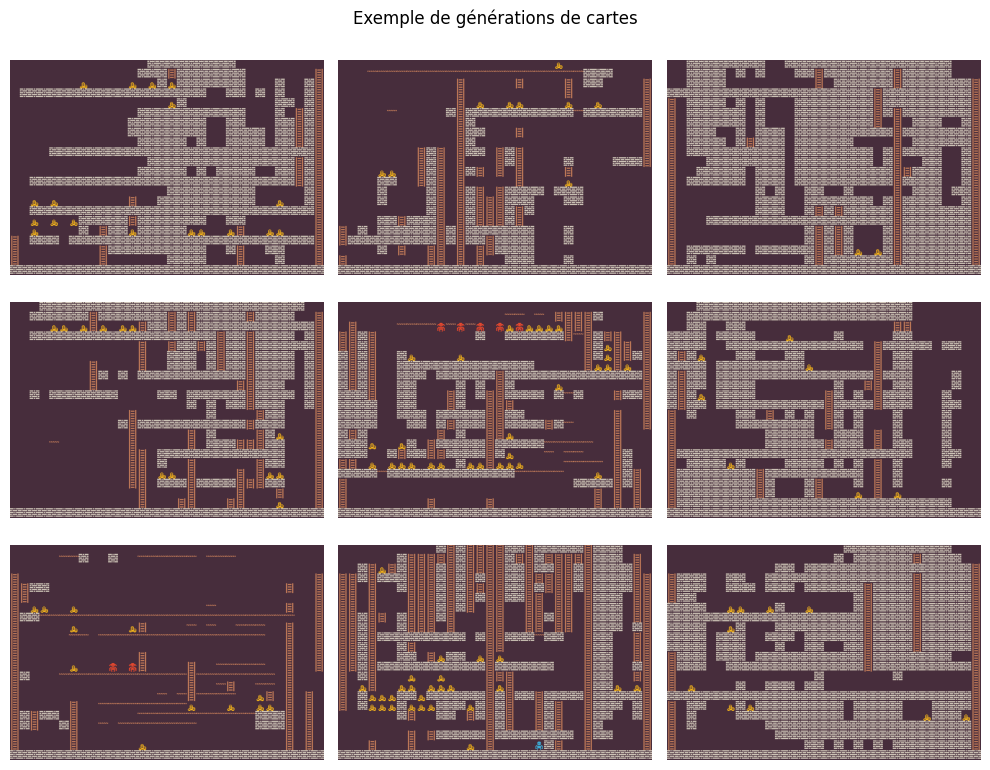

In [185]:
model_index = 4
with torch.no_grad():
    test_z = torch.randn(9, model_dims[model_index], device=device)
    tile_maps = models[model_index](test_z).detach().cpu().numpy().argmax(axis=1)[:,0:21,:]
    print(tile_maps.shape)
    # for single_map in tile_maps:
    #     plant_player(single_map)
    map_images = loderunner_env.render(tile_maps)


fig, axes = plt.subplots(3, 3, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(map_images[i])  # or images[i].permute(1,2,0) for torch CHW tensors
    ax.axis("off")
fig.suptitle("Exemple de générations de cartes")
plt.tight_layout()
plt.show()

In [230]:
def generate_maps(gen_model, z: np.ndarray):
    with torch.no_grad():
        z = np.atleast_2d(z)
        z_t = torch.tensor(z, dtype=torch.float32).to(device)
        # print("z_t", z_t.size())
        tile_maps = gen_model(z_t).detach().cpu().numpy().argmax(axis=1)[:,0:21,:] # Re-crop map to its normal row count (21)
    return tile_maps

In [272]:
import cma
def find_map_by_criteria(gen_model, model_dim, fitness_fnc, axes, ax_row):
    fitness_history = []

    es = cma.CMAEvolutionStrategy(np.zeros(model_dim), 0.9, {"verbose": -9})
    while not es.stop():
        solutions = es.ask()
        # print("sol shape ", len(solutions))
        maps = generate_maps(gen_model, solutions)
        fitnesses = [fitness_fnc(m) for m in maps]
        es.tell(solutions, [f for f in fitnesses])

        best_idx = np.argmax(fitnesses)
        fitness_history.append(fitnesses[best_idx])


    axes[ax_row, 0].plot(fitness_history)
    axes[ax_row, 0].set_title("Best fitness per generation")
    axes[ax_row, 0].set_xlabel("Generation")
    axes[ax_row, 0].set_ylabel("Fitness")
    
    return es, image_best_map

In [291]:



#########################

def countable_gold(sample_map):
    plant_player(sample_map)
    return float(np.abs(np.sum(sample_map == 3) -20))

def display_countable_gold(sample_map):
    plant_player(sample_map)
    return f"({np.abs(np.sum(sample_map == 3))} coins)"


#########################


def all_collectible_gold(sample_map):
    plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]

    gold_left = map_eval['collected_gold'] - map_eval['gold']
    return abs(gold_left) + abs(map_eval['gold'] -15) 

def display_all_collectible_gold(sample_map):
    plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]

    gold_left = map_eval['collected_gold'] - map_eval['gold']
    return f"({map_eval['collected_gold']}/{map_eval['gold']} coins)"

#########################

def all_collectible_a10_gold_and_enemies(sample_map):
    plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]
    return abs(map_eval['collected_gold'] - map_eval['gold']) + abs(map_eval['enemy'] -10) * 0.5 + abs(map_eval['gold'] -10) * 0.25

def display_all_collectible_a10_gold_and_enemies(sample_map):
    plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]

    gold_left = map_eval['collected_gold'] - map_eval['gold']
    return f"({map_eval['collected_gold']}/{map_eval['gold']} coins, {map_eval['enemy']} enem.)"

#########################

def all_collectible_a10_gold_and_enemies_one_player(sample_map):
    #plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]
    nb_players = np.sum(sample_map == 2)
    return abs(map_eval['collected_gold'] - map_eval['gold']) + abs(map_eval['enemy'] -10) * 0.5 + abs(map_eval['gold'] -10) * 0.25 + np.abs(nb_players - 1) * 20

def display_all_collectible_a10_gold_and_enemies_one_player(sample_map):
    #plant_player(sample_map)
    map_eval = loderunner_env.evaluate(sample_map)[4]
    nb_players = np.sum(sample_map == 2)
    gold_left = map_eval['collected_gold'] - map_eval['gold']
    return f"({map_eval['collected_gold']}/{map_eval['gold']} coins, {map_eval['enemy']} enem., {nb_players} player(s))"

In [295]:
def test_fitness_function(fitness_fnc_test, display_fnc, title, put_one_player=True):
    nb_models = len(model_names)
    fig, axes = plt.subplots(nb_models, 2, figsize=(8, nb_models * 3))
    for i in range(nb_models):
        current_model = models[i]
        model_dim = model_dims[i]
        
        es_search, image_best_map = find_map_by_criteria(
            gen_model=current_model, 
            model_dim=model_dim, 
            fitness_fnc=fitness_fnc_test,
            axes=axes,
            ax_row=i)

        # Draw best map
        best_map = generate_maps(current_model, es_search.result.xbest)[0]

        if put_one_player:
            plant_player(best_map)
            
        image_best_map = loderunner_env.render(best_map)
        axes[i, 1].set_title(f"{model_names[i]} {display_fnc(best_map)}")
        axes[i, 1].imshow(image_best_map)
        axes[i, 1].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

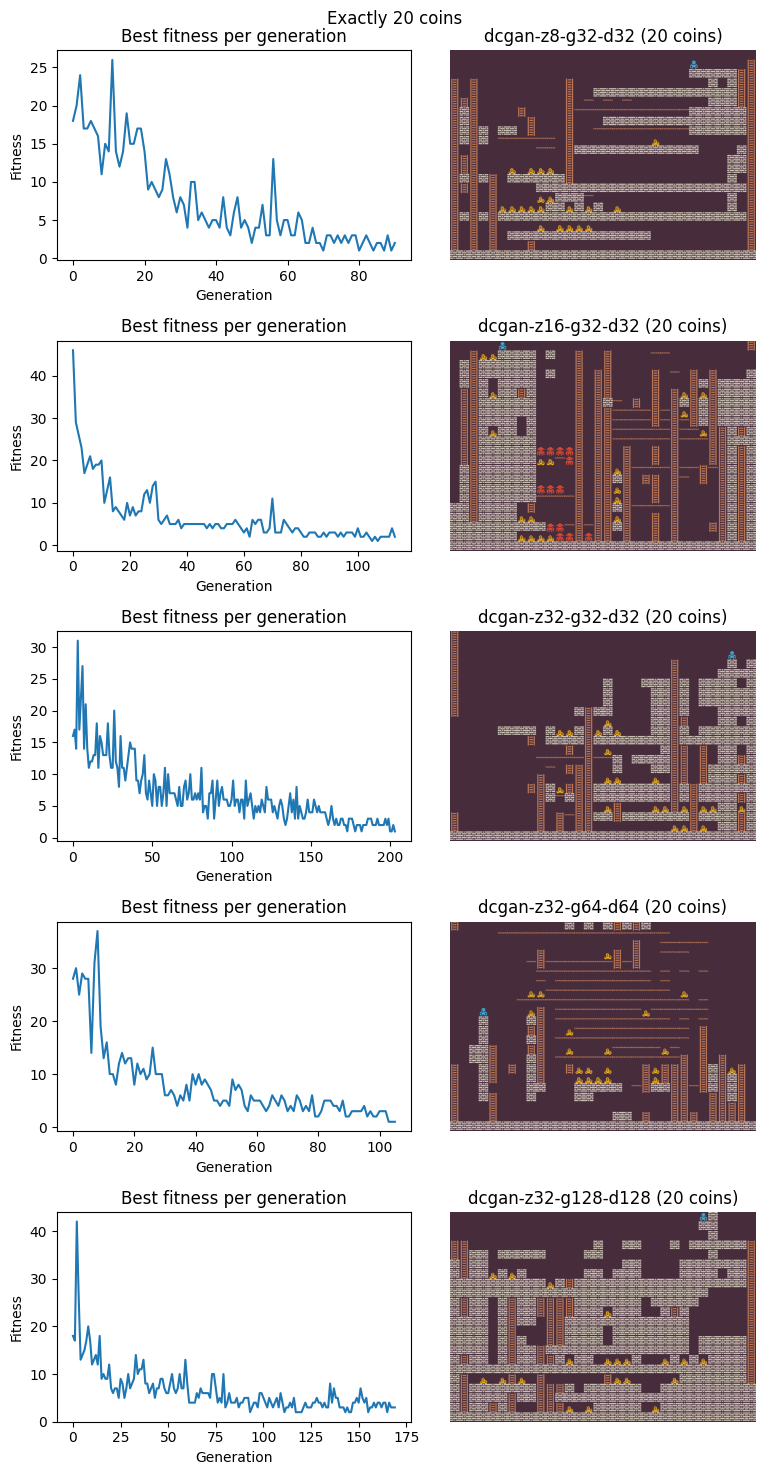

In [278]:
test_fitness_function(countable_gold, display_countable_gold, "Exactly 20 coins")

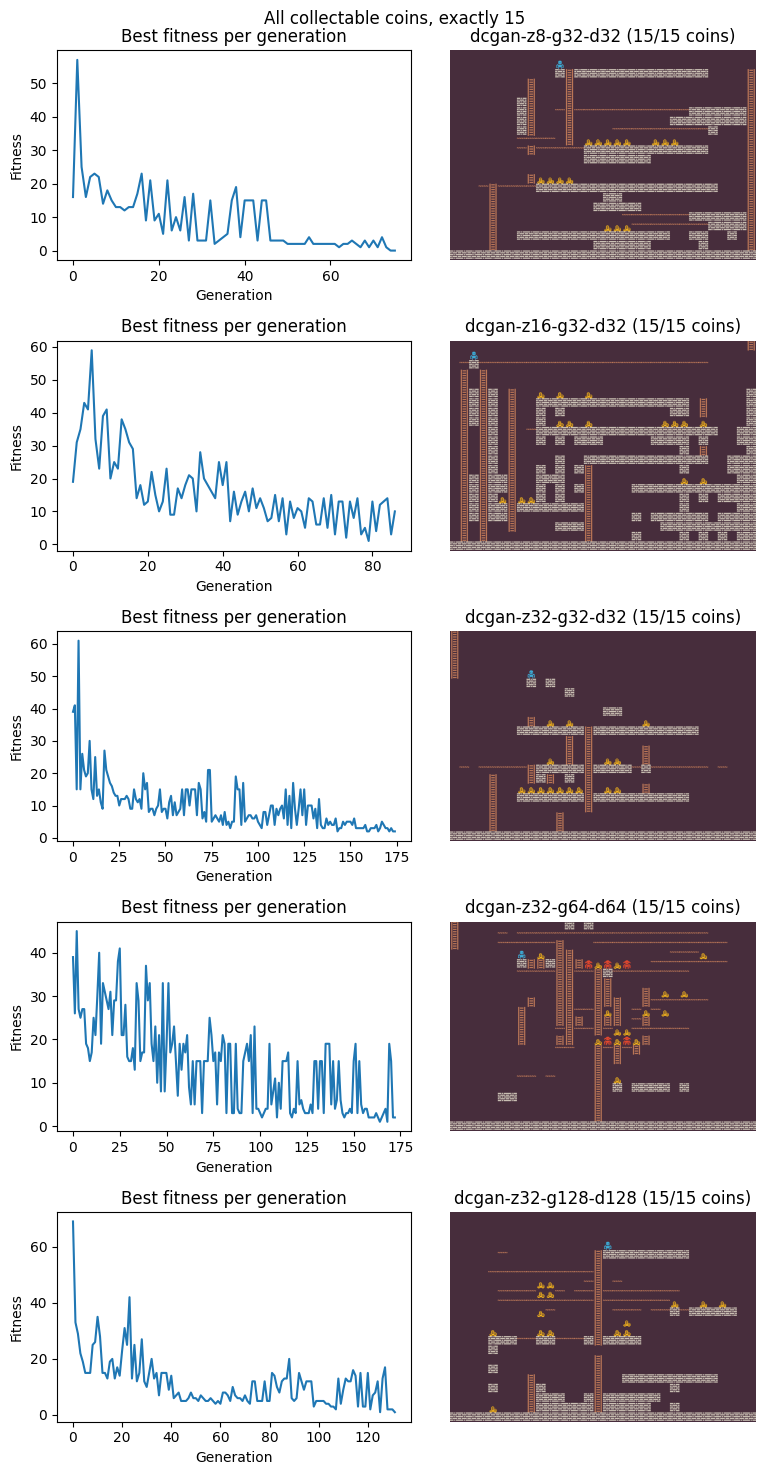

In [285]:
test_fitness_function(all_collectible_gold, display_all_collectible_gold, "All collectable coins, exactly 15")

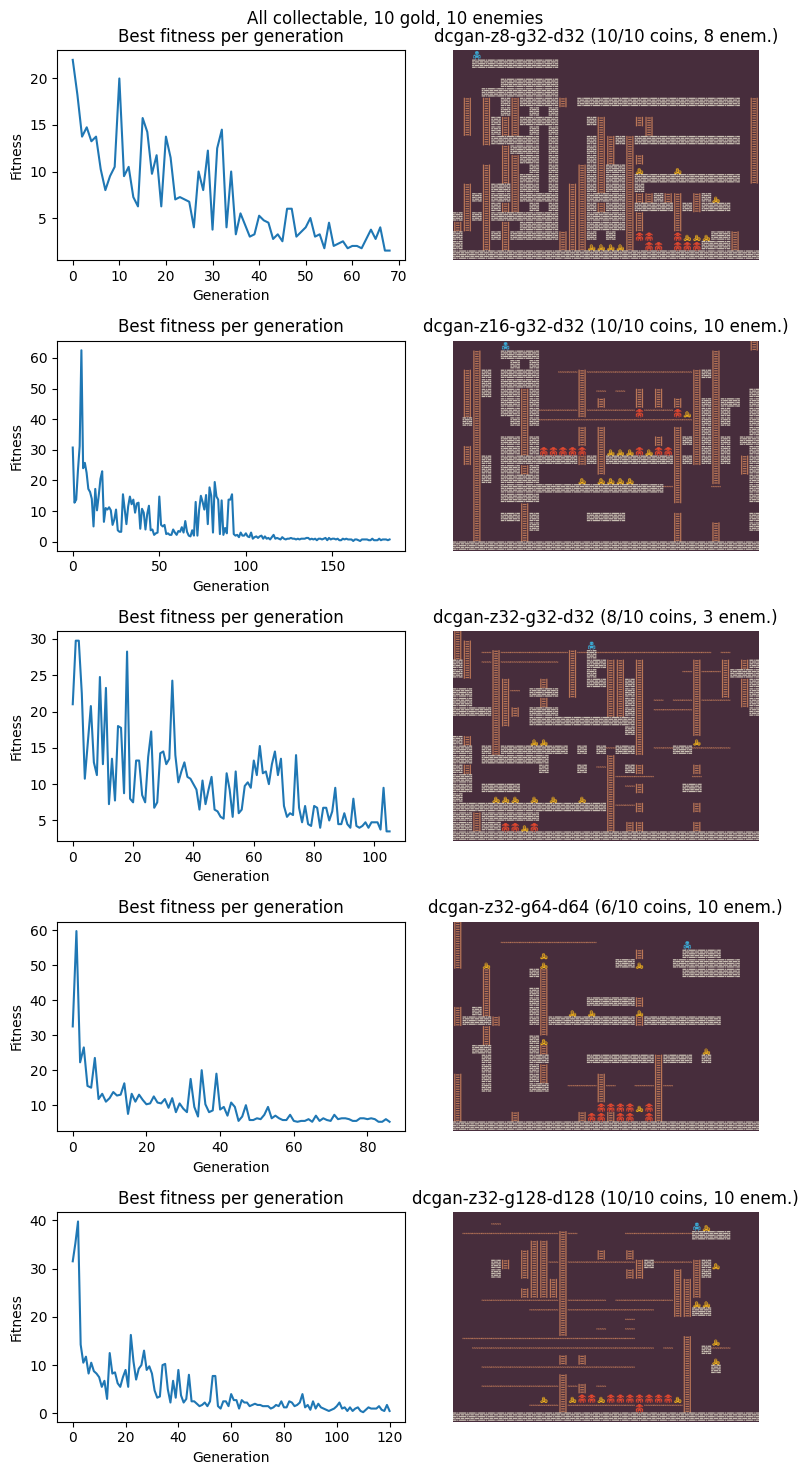

In [289]:
test_fitness_function(all_collectible_a10_gold_and_enemies, display_all_collectible_a10_gold_and_enemies, "All collectable, 10 gold, 10 enemies")

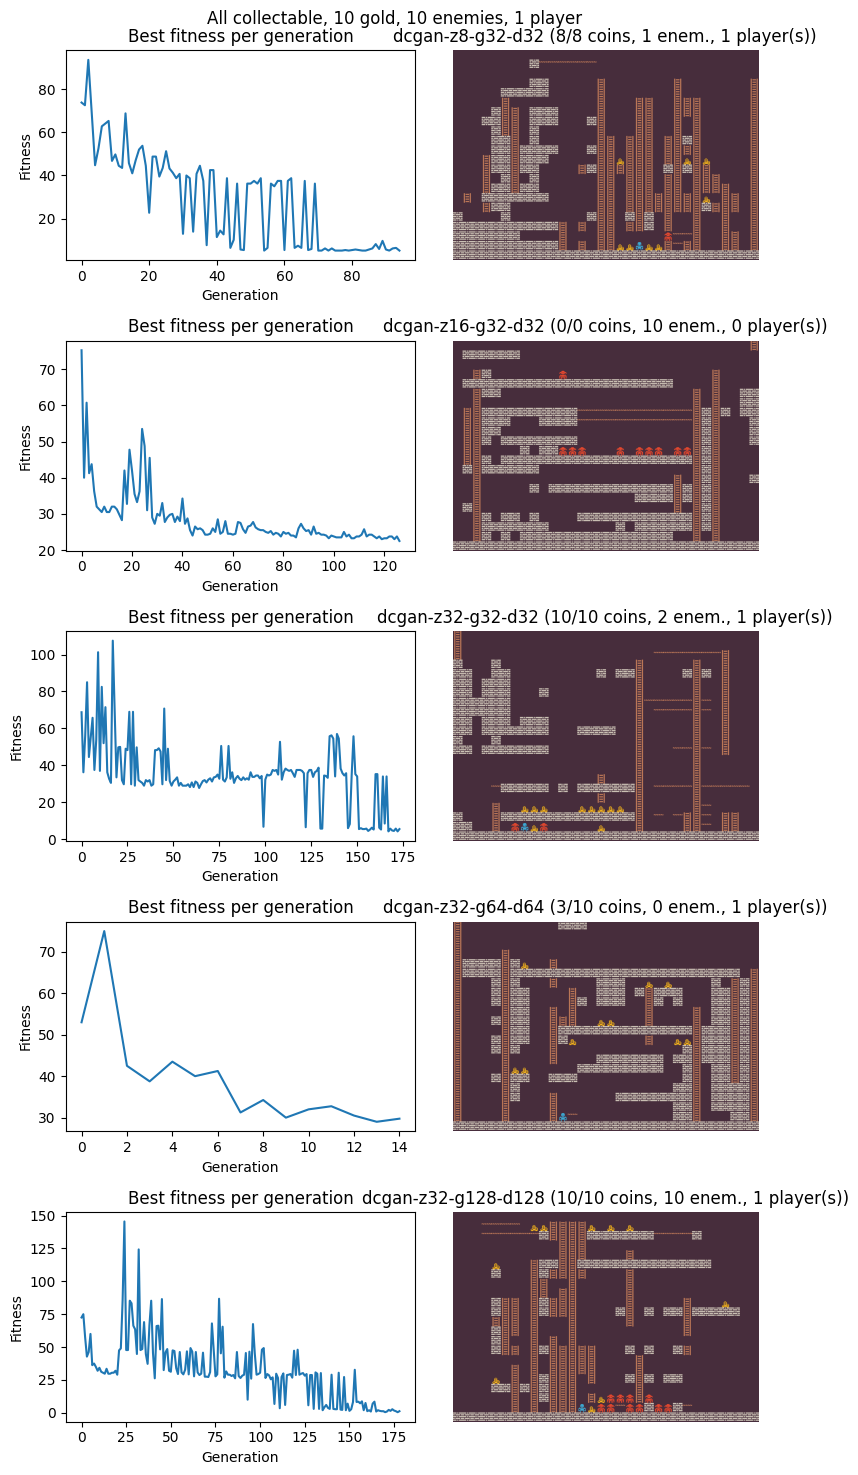

In [297]:
test_fitness_function(all_collectible_a10_gold_and_enemies_one_player, display_all_collectible_a10_gold_and_enemies_one_player, "All collectable, 10 gold, 10 enemies, 1 player", put_one_player=False)